In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Set environment variables
import os

os.environ["SCAL_TYPE"] = "complex"
os.environ["PRECISION"] = "single"
os.environ["MY_NUMBA_TARGET"] = "numba"
 
# Add cle_fun to PYTHON_PATH
import sys
sys.path.append("../../clonscal")

In [24]:
from simulation.config import Config
from simulation.cl_simulation import ComplexLangevinSimulation
from src.obs_kernels import n_moment_kernel
from tqdm import tqdm

By modifiying the action
$$
\tilde{S} = S - \log(1+R(z)e^S)
$$
and accordingly the density
$$
\tilde{\rho} = \rho+R(z) = \rho+r\exp{(-az^2/2)}
$$
we change the theory and in general also the observables
$$
\langle O \rangle_{\tilde{\rho}} \neq \langle O \rangle_{\rho}
$$
We have to compensate for this by subtracting a bias induced by the modification. We do this by identifying
$$
\langle O \rangle_{\rho} = \langle O \rangle_{\tilde{\rho}} + (\langle O \rangle_{\tilde{\rho}}-\langle O \rangle_{R}) Q
$$
where $Q$ is an observable independent scalar. For a given observable $O$ we may construct a observable $O^*$, whose expectation value vanishes in the umodifed theory. Q then reduces to

$$
Q = \frac{ \langle O^* \rangle_{\tilde{\rho}}}{\langle O^* \rangle_R - \langle O^* \rangle_{\tilde{\rho}}} = \frac{\langle \mathcal{O}^*_{m} \rangle_{\tilde{\rho}}}{\frac{m(m-2)!!}{a^{(m-1)/2}} - \sigma\frac{m!!}{a^{(m+1)/2}} - \lambda\frac{(m+2)!!}{a^{(m+3)/2}} - \langle \mathcal{O}^*_{m} \rangle_{\tilde{\rho}}}
$$
for odd m



In [25]:
# Sim parameters
lamb = 1
sigma_abs = 2

start_angle = 0
stop_angle = 2*np.pi

num_cl = 8
angles_cl = np.linspace(start_angle, stop_angle, num_cl)
sigma_vals_cl = sigma_abs*(np.cos(angles_cl) + 1j*np.sin(angles_cl))

In [26]:
def calculate_stats_complex(rolling_mean, rolling_sqr_mean, counter):
    """
    Calculate mean and SEM for complex numbers.
    
    Parameters:
    rolling_mean (np.array): Single-element array containing the rolling sum of complex values.
    rolling_sqr_mean (np.array): Single-element array containing the rolling sum of squared magnitudes of complex values.
    counter (np.array): Single-element array containing the number of values.
    
    Returns:
    tuple: (mean, sem_real, sem_imag), where:
        - mean is the complex mean,
        - sem_real is the SEM for the real part,
        - sem_imag is the SEM for the imaginary part.
    """
    if counter == 0:
        raise ValueError("Counter cannot be zero to avoid division by zero.")
    
    # Extract real and imaginary parts
    rolling_mean_real = rolling_mean.real
    rolling_mean_imag = rolling_mean.imag
    
    # Mean calculation
    mean_real = rolling_mean_real / counter
    mean_imag = rolling_mean_imag / counter
    
    # Variance for real part
    rolling_sqr_mean_real = rolling_sqr_mean
    variance = (rolling_sqr_mean_real / counter) - mean_real**2 - mean_imag**2
    variance = max(variance, 0)
        
    # Standard error of the mean (SEM)
    sem = np.sqrt(variance / counter)
    
    # Return complex mean and SEM for real and imaginary parts
    mean = mean_real + 1j * mean_imag
    return mean, sem


In [27]:
mass_modification = 1
pullback = 10

In [28]:
# Running the simulation
from simulation.config import Config
from simulation.cl_simulation import ComplexLangevinSimulation
from src.obs_kernels import n_moment_kernel, skew_action, dse_n_moment_kernel
from src.utils import gaussian_modified_density_drift_kernel
from tqdm import tqdm

cl_estimate_dict = {'dse_1_moment': [], 'dse_3_moment': [], 'dse_5_moment': []}
errors_dict = {'dse_1_moment': [], 'dse_3_moment': [], 'dse_5_moment': []}
steps = int(1e5)
trajs = int(1e3)

for angle, sigma in zip(angles_cl, (sigma_vals_cl)):
    config = Config(dt = 5e-4, trajs = trajs, dims = [1], mass_real = sigma, interaction = lamb, ada_step = True, drift_kernel=gaussian_modified_density_drift_kernel,
                    mass_modification=mass_modification, pullback = pullback)
    sim_dse = ComplexLangevinSimulation(config)
    sim_dse.register_observable('dse_1_moment', obs_kernel=dse_n_moment_kernel, const_param={"order" : 1},  langevin_history=False, thermal_time=1, auto_corr=1)
    sim_dse.register_observable('dse_3_moment', obs_kernel=dse_n_moment_kernel, const_param={"order" : 3},  langevin_history=False, thermal_time=1, auto_corr=1)
    sim_dse.register_observable('dse_5_moment', obs_kernel=dse_n_moment_kernel, const_param={"order" : 5},  langevin_history=False, thermal_time=1, auto_corr=1)

    for _ in tqdm(range(steps)):
        sim_dse.step()
        for name, tr in sim_dse.trackers.items():
            tr.mark_equilibrated_trajs()
            tr.compute()
    sim_dse.finish()

    for name, tr in sim_dse.trackers.items():
        mean, sem = calculate_stats_complex(tr.rolling_mean, tr.rolling_sqr_mean, tr.counter)
        cl_estimate_dict[name].append(mean)
        errors_dict[name].append(sem)

100%|██████████| 100000/100000 [00:20<00:00, 4940.47it/s]


In [30]:
# import numpy as np
# from scipy.integrate import quad
# from numba import jit

# # define obs that vanishes wrt rho
# def n_moment_dse(x, order, sigma, lamb):
#     return order*x**(order-1)-x**order * (sigma * x + lamb * x*x*x)

# # define rho and R
# @jit
# def action(x, sigma, lamb): return sigma/2*x**2+lamb/4*x**4

# @jit
# def rho(x, sigma, lamb): return np.exp(-action(x, sigma, lamb))

# @jit
# def R(x, r, a): return r*np.exp(-a*x**2/2)

# @jit
# def rho_tilde(x, r, a, sigma, lamb): return rho(x, sigma, lamb)+R(x, r, a)

# # define partition sums
# def z_rho(sigma, lamb): 
#     real_part = quad(lambda x: np.real(rho(x, sigma, lamb)), -np.inf, np.inf)[0]
#     imag_part = quad(lambda x: np.imag(rho(x, sigma, lamb)), -np.inf, np.inf)[0]
#     return real_part+1j*imag_part

# def z_rho_tilde(r, a, sigma, lamb): 
#     real_part = quad(lambda x: np.real(rho_tilde(x, r, a, sigma, lamb)), -np.inf, np.inf)[0]
#     imag_part = quad(lambda x: np.imag(rho_tilde(x, r, a, sigma, lamb)), -np.inf, np.inf)[0]
#     return real_part+1j*imag_part

# def z_R(r, a, sigma, lamb): 
#     real_part = quad(lambda x: np.real(R(x, r, a)), -np.inf, np.inf)[0]
#     imag_part = quad(lambda x: np.imag(R(x, r, a)), -np.inf, np.inf)[0]
#     return real_part+1j*imag_part

# # define exp val of n_moment_dse wrt rho_tilde
# @np.vectorize
# def n_moment_dse_rho_tilde(order, r, a, sigma, lamb):
#     real_part = quad(lambda x: np.real(rho_tilde(x, r, a, sigma, lamb)*n_moment_dse(x, order, sigma, lamb)), 
#                      -np.inf, np.inf)[0]
#     imag_part = quad(lambda x: np.imag(rho_tilde(x, r, a, sigma, lamb)*n_moment_dse(x, order, sigma, lamb)), 
#                      -np.inf, np.inf)[0]
#     out = real_part + 1j*imag_part
#     return out / z_rho_tilde(r, a, sigma, lamb)
    
# # define exp val of n_moment_dse wrt rho
# @np.vectorize
# def n_moment_dse_rho(order, sigma, lamb):
#     real_part = quad(lambda x: np.real(rho(x, sigma, lamb)*n_moment_dse(x, order, sigma, lamb)), 
#                      -np.inf, np.inf)[0]
#     imag_part = quad(lambda x: np.imag(rho(x, sigma, lamb)*n_moment_dse(x, order, sigma, lamb)), 
#                      -np.inf, np.inf)[0]
#     out = real_part + 1j*imag_part
#     return out / z_rho(sigma, lamb)

# # define exp val of n_moment_dse wrt R
# @np.vectorize
# def n_moment_dse_R(order, r, a, sigma, lamb):
#     real_part = quad(lambda x: np.real(R(x, r, a)*n_moment_dse(x, order, sigma, lamb)), 
#                      -np.inf, np.inf)[0]
#     imag_part = quad(lambda x: np.imag(R(x, r, a)*n_moment_dse(x, order, sigma, lamb)), 
#                      -np.inf, np.inf)[0]
#     out = real_part + 1j*imag_part
#     return out / z_R(r, a, sigma, lamb)

     
# import scipy
# # define analytic resul for n_moment_dse wrt R
# @np.vectorize
# def n_moment_dse_R_analytic(order, r, a, sigma, lamb):
#     if order > 1:
#         out = order*scipy.special.factorial2(order-2)/np.power(a, (order-1)//2)
#     else:
#         out = 1
#     out -= sigma*scipy.special.factorial2(order)/ np.power(a, (order+1)//2) 
#     out -= lamb*scipy.special.factorial2(order+2)/np.power(a, (order+3)//2)
#     return out

In [31]:
import numpy as np
from scipy.integrate import quad
from numba import jit

# define obs that vanishes wrt rho
def n_moment_dse(x, order, sigma, lamb):
    return order*x**(order-1)-x**order * (sigma * x + lamb * x*x*x)

# define rho and R
@jit
def action(x, sigma, lamb): return sigma/2*x**2+lamb/4*x**4

@jit
def rho(x, sigma, lamb): return np.exp(-action(x, sigma, lamb))

@jit
def R(x, r, a): return r*np.exp(-a*x**2/2)

@jit
def rho_tilde(x, r, a, sigma, lamb): return rho(x, sigma, lamb)+R(x, r, a)

# define partition sums
def z_rho(sigma, lamb): 
    real_part = quad(lambda x: np.real(rho(x, sigma, lamb)), -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho(x, sigma, lamb)), -np.inf, np.inf)[0]
    return real_part+1j*imag_part

def z_rho_tilde(r, a, sigma, lamb): 
    real_part = quad(lambda x: np.real(rho_tilde(x, r, a, sigma, lamb)), -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho_tilde(x, r, a, sigma, lamb)), -np.inf, np.inf)[0]
    return real_part+1j*imag_part

def z_R(r, a, sigma, lamb): 
    real_part = quad(lambda x: np.real(R(x, r, a)), -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(R(x, r, a)), -np.inf, np.inf)[0]
    return real_part+1j*imag_part

# define exp val of n_moment_dse wrt rho_tilde
@np.vectorize
def n_moment_dse_rho_tilde(order, r, a, sigma, lamb):
    real_part = quad(lambda x: np.real(rho_tilde(x, r, a, sigma, lamb)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho_tilde(x, r, a, sigma, lamb)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_rho_tilde(r, a, sigma, lamb)
    
# define exp val of n_moment_dse wrt rho
@np.vectorize
def n_moment_dse_rho(order, sigma, lamb):
    real_part = quad(lambda x: np.real(rho(x, sigma, lamb)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho(x, sigma, lamb)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_rho(sigma, lamb)

# define exp val of n_moment_dse wrt R
@np.vectorize
def n_moment_dse_R(order, r, a, sigma, lamb):
    real_part = quad(lambda x: np.real(R(x, r, a)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(R(x, r, a)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_R(r, a, sigma, lamb)

     
import scipy
# define analytic resul for n_moment_dse wrt R
@np.vectorize
def n_moment_dse_R_analytic(order, r, a, sigma, lamb):
    if order > 1:
        out = order*scipy.special.factorial2(order-2)/np.power(a, (order-1)//2)
    else: 
        out = 1
    out -= sigma*scipy.special.factorial2(order)/ np.power(a, (order+1)//2) 
    out -= lamb*scipy.special.factorial2(order+2)/np.power(a, (order+3)//2)
    return out

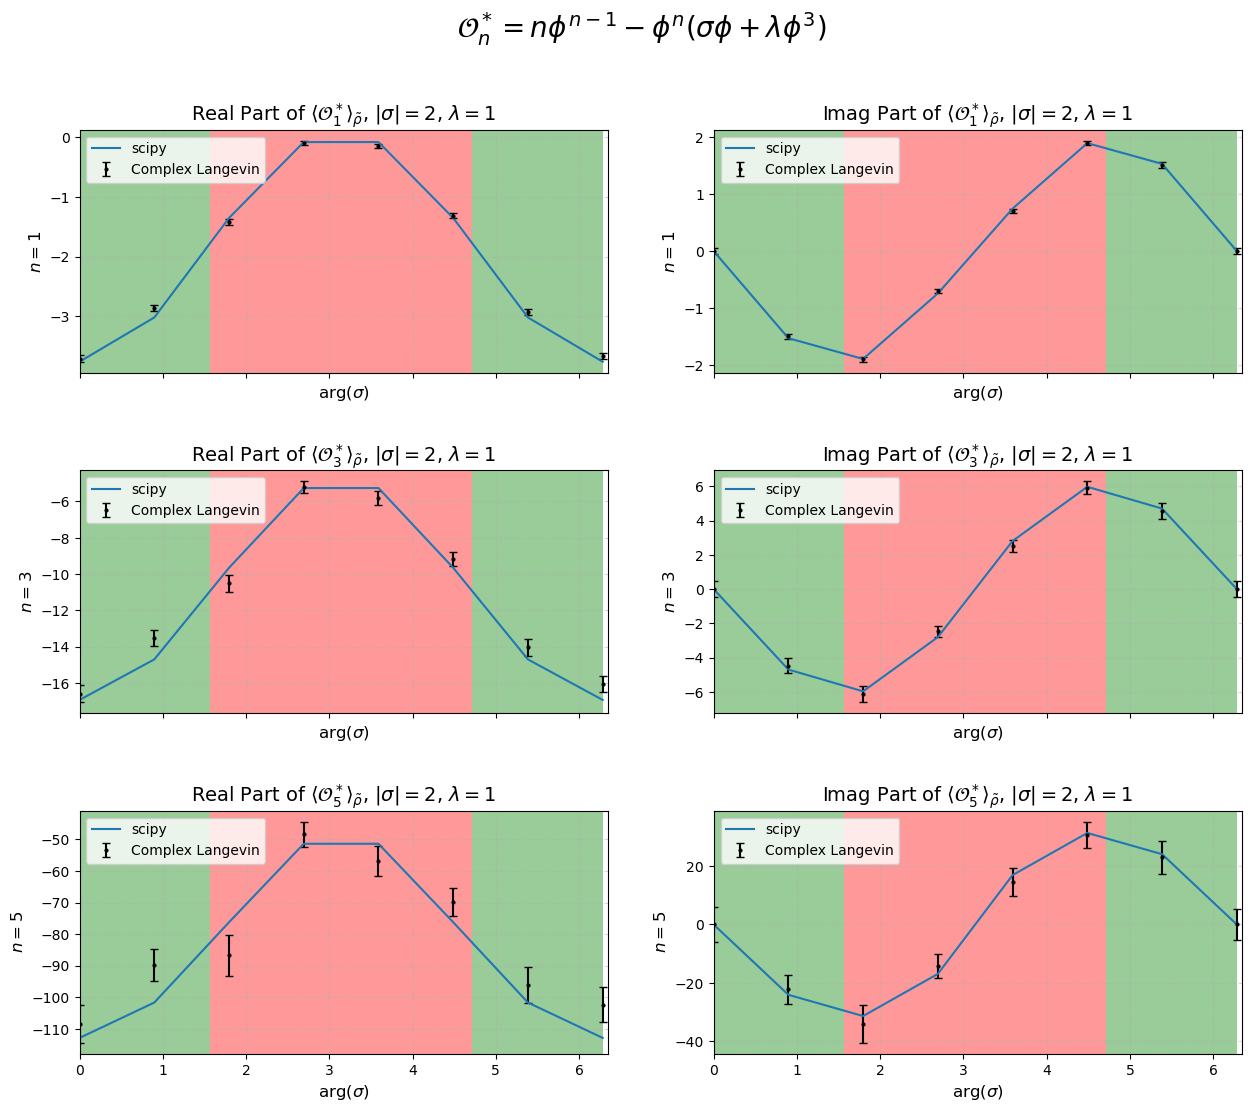

In [32]:
fig, axes = plt.subplots(3, 2, figsize=(15, 4*3), sharex=True) 
fig.suptitle(rf"$\mathcal{{O}}^*_n=n \phi^{{n-1}}-\phi^n (\sigma\phi+\lambda \phi^3)$", fontsize = 20)
fig.subplots_adjust(hspace=0.4, wspace=0.2)  # Adjust spacing between subplots

for (name, tr), ax in zip(sim_dse.trackers.items(), axes):
    order = tr.order
    # CL data
    cl_estimate = np.array(cl_estimate_dict[name])
    errors = np.array(errors_dict[name])

    ax[0].errorbar(angles_cl, cl_estimate.real, yerr=errors, fmt='o',color='black', capsize=3 ,label='Complex Langevin', markersize=2)
    ax[1].errorbar(angles_cl, cl_estimate.imag, yerr=errors, fmt='o',color='black', capsize=3 ,label='Complex Langevin', markersize=2)

    # ax[0].errorbar(angles_cl, q_cl.real, yerr=2*np.abs(error_prop*errors), fmt='o',color='black', capsize=3 ,label='Complex Langevin', markersize=2)
    # ax[1].errorbar(angles_cl, q_cl.imag, yerr=2*np.abs(error_prop*errors), fmt='o',color='black', capsize=3 ,label='Complex Langevin', markersize=2)

    # Titles
    ax[0].set_title(rf'Real Part of $\langle \mathcal{{O}}^*_{{{order}}}\rangle_{{\tilde{{\rho}}}}$'+r', $|\sigma| = $'+f"{sigma_abs}"+r', $\lambda=$'+f"{lamb}", fontsize=14)
    ax[1].set_title(rf'Imag Part of $\langle \mathcal{{O}}^*_{{{order}}}\rangle_{{\tilde{{\rho}}}}$'+r', $|\sigma| = $'+f"{sigma_abs}"+r', $\lambda=$'+f"{lamb}", fontsize=14)

    # Thimble Sectors
    for ax_ in ax: 
        ax_.axvspan(0, np.pi/2, facecolor='green', alpha=0.4)
        ax_.axvspan(np.pi/2, 3*np.pi/2, facecolor='red', alpha=0.4)
        ax_.axvspan(3*np.pi/2, 2*np.pi, facecolor='green', alpha=0.4)
    vals_rho_tilde = n_moment_dse_rho_tilde(r=pullback, a=mass_modification, order= order, sigma=sigma_vals_cl, lamb=lamb)

    ax[0].plot(angles_cl, np.real(vals_rho_tilde), label=rf"scipy")
    ax[1].plot(angles_cl, np.imag(vals_rho_tilde), label=rf"scipy")

    # q_ana = 1 / (vals_R/vals_rho_tilde - 1)
    # ax[0].plot(angles_cl, np.real(q_ana), label=rf"scipy")
    # ax[1].plot(angles_cl, np.imag(q_ana), label=rf"scipy")
        
    # Formatting
    for ax_ in ax:
        ax_.set_xlabel(r'arg($\sigma$)', fontsize=12)
        ax_.grid(alpha=0.5, linestyle='--')
        ax_.legend(fontsize=10, loc = 'upper left')
        ax_.tick_params(axis='both', which='major', labelsize=10)
    
    # axes[0].set_ylim(-1, 1

    ax[0].set_xlim(angles_cl.min()*1.01, angles_cl.max()*1.01)
    ax[1].set_xlim(angles_cl.min()*1.01, angles_cl.max()*1.01)
    if order > 0: label = rf"$\langle {{{order}}} \cdot \phi^{{{order-1}}} - \phi^{{{order}}}(\sigma \phi + \lambda \phi^3) \rangle$"
    else: label = rf"$\langle \phi^{{{order}}}(\sigma \phi + \lambda \phi^3) \rangle$"

    ax[0].set_ylabel(rf'$n={{{order}}}$', fontsize=12)
    ax[1].set_ylabel(rf'$n={{{order}}}$', fontsize=12)

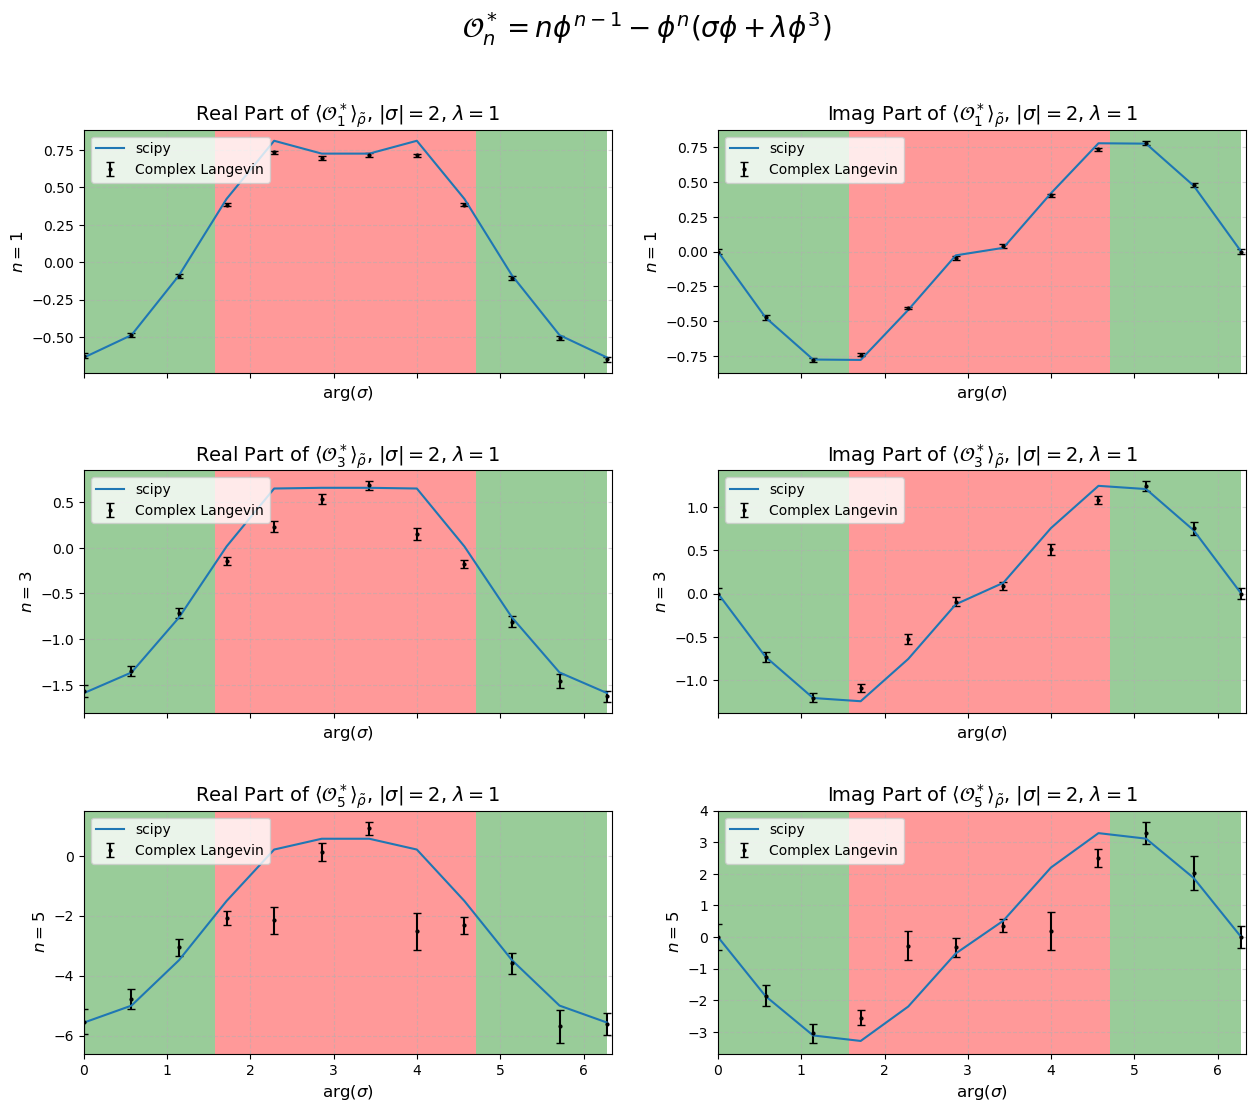

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(15, 4*3), sharex=True) 
fig.suptitle(rf"$\mathcal{{O}}^*_n=n \phi^{{n-1}}-\phi^n (\sigma\phi+\lambda \phi^3)$", fontsize = 20)
fig.subplots_adjust(hspace=0.4, wspace=0.2)  # Adjust spacing between subplots

for (name, tr), ax in zip(sim_dse.trackers.items(), axes):
    order = tr.order
    # CL data
    cl_estimate = np.array(cl_estimate_dict[name])
    errors = np.array(errors_dict[name])

    ax[0].errorbar(angles_cl, cl_estimate.real, yerr=errors, fmt='o',color='black', capsize=3 ,label='Complex Langevin', markersize=2)
    ax[1].errorbar(angles_cl, cl_estimate.imag, yerr=errors, fmt='o',color='black', capsize=3 ,label='Complex Langevin', markersize=2)

    # ax[0].errorbar(angles_cl, q_cl.real, yerr=2*np.abs(error_prop*errors), fmt='o',color='black', capsize=3 ,label='Complex Langevin', markersize=2)
    # ax[1].errorbar(angles_cl, q_cl.imag, yerr=2*np.abs(error_prop*errors), fmt='o',color='black', capsize=3 ,label='Complex Langevin', markersize=2)

    # Titles
    ax[0].set_title(rf'Real Part of $\langle \mathcal{{O}}^*_{{{order}}}\rangle_{{\tilde{{\rho}}}}$'+r', $|\sigma| = $'+f"{sigma_abs}"+r', $\lambda=$'+f"{lamb}", fontsize=14)
    ax[1].set_title(rf'Imag Part of $\langle \mathcal{{O}}^*_{{{order}}}\rangle_{{\tilde{{\rho}}}}$'+r', $|\sigma| = $'+f"{sigma_abs}"+r', $\lambda=$'+f"{lamb}", fontsize=14)

    # Thimble Sectors
    for ax_ in ax: 
        ax_.axvspan(0, np.pi/2, facecolor='green', alpha=0.4)
        ax_.axvspan(np.pi/2, 3*np.pi/2, facecolor='red', alpha=0.4)
        ax_.axvspan(3*np.pi/2, 2*np.pi, facecolor='green', alpha=0.4)
    vals_rho_tilde = n_moment_dse_rho_tilde(r=pullback, a=mass_modification, order= order, sigma=sigma_vals_cl, lamb=lamb)

    ax[0].plot(angles_cl, np.real(vals_rho_tilde), label=rf"scipy")
    ax[1].plot(angles_cl, np.imag(vals_rho_tilde), label=rf"scipy")

    # q_ana = 1 / (vals_R/vals_rho_tilde - 1)
    # ax[0].plot(angles_cl, np.real(q_ana), label=rf"scipy")
    # ax[1].plot(angles_cl, np.imag(q_ana), label=rf"scipy")
        
    # Formatting
    for ax_ in ax:
        ax_.set_xlabel(r'arg($\sigma$)', fontsize=12)
        ax_.grid(alpha=0.5, linestyle='--')
        ax_.legend(fontsize=10, loc = 'upper left')
        ax_.tick_params(axis='both', which='major', labelsize=10)
    
    # axes[0].set_ylim(-1, 1

    ax[0].set_xlim(angles_cl.min()*1.01, angles_cl.max()*1.01)
    ax[1].set_xlim(angles_cl.min()*1.01, angles_cl.max()*1.01)
    if order > 0: label = rf"$\langle {{{order}}} \cdot \phi^{{{order-1}}} - \phi^{{{order}}}(\sigma \phi + \lambda \phi^3) \rangle$"
    else: label = rf"$\langle \phi^{{{order}}}(\sigma \phi + \lambda \phi^3) \rangle$"

    ax[0].set_ylabel(rf'$n={{{order}}}$', fontsize=12)
    ax[1].set_ylabel(rf'$n={{{order}}}$', fontsize=12)

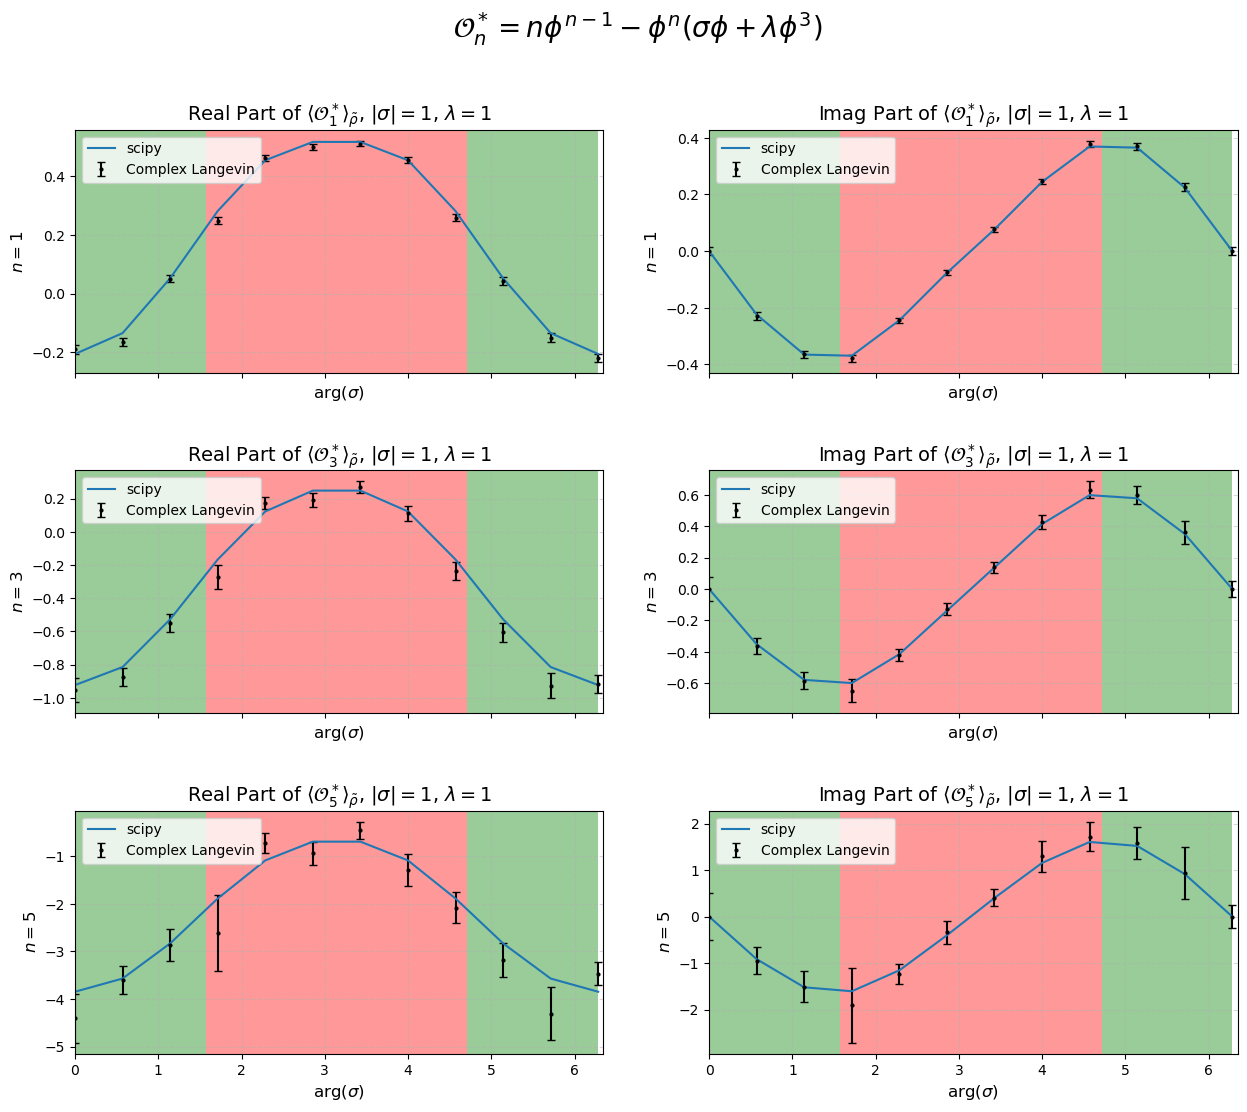

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(15, 4*3), sharex=True) 
fig.suptitle(rf"$\mathcal{{O}}^*_n=n \phi^{{n-1}}-\phi^n (\sigma\phi+\lambda \phi^3)$", fontsize = 20)
fig.subplots_adjust(hspace=0.4, wspace=0.2)  # Adjust spacing between subplots

for (name, tr), ax in zip(sim_dse.trackers.items(), axes):
    order = tr.order
    # CL data
    cl_estimate = np.array(cl_estimate_dict[name])
    errors = np.array(errors_dict[name])

    ax[0].errorbar(angles_cl, cl_estimate.real, yerr=errors, fmt='o',color='black', capsize=3 ,label='Complex Langevin', markersize=2)
    ax[1].errorbar(angles_cl, cl_estimate.imag, yerr=errors, fmt='o',color='black', capsize=3 ,label='Complex Langevin', markersize=2)

    # ax[0].errorbar(angles_cl, q_cl.real, yerr=2*np.abs(error_prop*errors), fmt='o',color='black', capsize=3 ,label='Complex Langevin', markersize=2)
    # ax[1].errorbar(angles_cl, q_cl.imag, yerr=2*np.abs(error_prop*errors), fmt='o',color='black', capsize=3 ,label='Complex Langevin', markersize=2)

    # Titles
    ax[0].set_title(rf'Real Part of $\langle \mathcal{{O}}^*_{{{order}}}\rangle_{{\tilde{{\rho}}}}$'+r', $|\sigma| = $'+f"{sigma_abs}"+r', $\lambda=$'+f"{lamb}", fontsize=14)
    ax[1].set_title(rf'Imag Part of $\langle \mathcal{{O}}^*_{{{order}}}\rangle_{{\tilde{{\rho}}}}$'+r', $|\sigma| = $'+f"{sigma_abs}"+r', $\lambda=$'+f"{lamb}", fontsize=14)

    # Thimble Sectors
    for ax_ in ax: 
        ax_.axvspan(0, np.pi/2, facecolor='green', alpha=0.4)
        ax_.axvspan(np.pi/2, 3*np.pi/2, facecolor='red', alpha=0.4)
        ax_.axvspan(3*np.pi/2, 2*np.pi, facecolor='green', alpha=0.4)
    vals_rho_tilde = n_moment_dse_rho_tilde(r=pullback, a=mass_modification, order= order, sigma=sigma_vals_cl, lamb=lamb)

    ax[0].plot(angles_cl, np.real(vals_rho_tilde), label=rf"scipy")
    ax[1].plot(angles_cl, np.imag(vals_rho_tilde), label=rf"scipy")

    # q_ana = 1 / (vals_R/vals_rho_tilde - 1)
    # ax[0].plot(angles_cl, np.real(q_ana), label=rf"scipy")
    # ax[1].plot(angles_cl, np.imag(q_ana), label=rf"scipy")
        
    # Formatting
    for ax_ in ax:
        ax_.set_xlabel(r'arg($\sigma$)', fontsize=12)
        ax_.grid(alpha=0.5, linestyle='--')
        ax_.legend(fontsize=10, loc = 'upper left')
        ax_.tick_params(axis='both', which='major', labelsize=10)
    
    # axes[0].set_ylim(-1, 1

    ax[0].set_xlim(angles_cl.min()*1.01, angles_cl.max()*1.01)
    ax[1].set_xlim(angles_cl.min()*1.01, angles_cl.max()*1.01)
    if order > 0: label = rf"$\langle {{{order}}} \cdot \phi^{{{order-1}}} - \phi^{{{order}}}(\sigma \phi + \lambda \phi^3) \rangle$"
    else: label = rf"$\langle \phi^{{{order}}}(\sigma \phi + \lambda \phi^3) \rangle$"

    ax[0].set_ylabel(rf'$n={{{order}}}$', fontsize=12)
    ax[1].set_ylabel(rf'$n={{{order}}}$', fontsize=12)

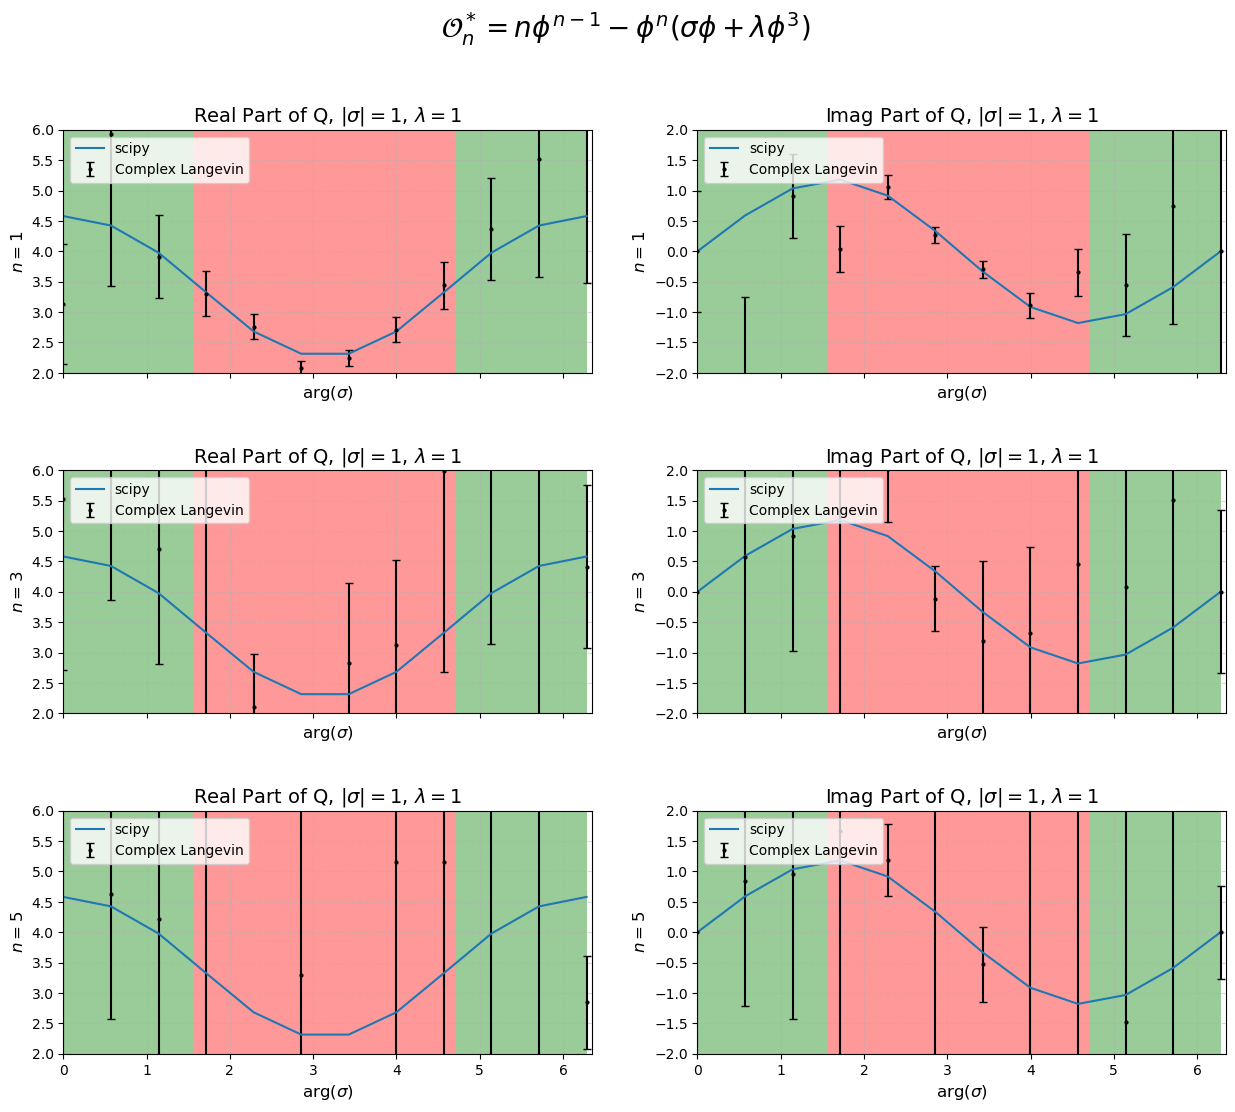

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(15, 4*3), sharex=True) 
fig.suptitle(rf"$\mathcal{{O}}^*_n=n \phi^{{n-1}}-\phi^n (\sigma\phi+\lambda \phi^3)$", fontsize = 20)
fig.subplots_adjust(hspace=0.4, wspace=0.2)  # Adjust spacing between subplots


for (name, tr), ax in zip(sim_dse.trackers.items(), axes):

    order = tr.order
    # CL data
    cl_estimate = np.array(cl_estimate_dict[name])
    errors = np.array(errors_dict[name])

    vals_R = n_moment_dse_R_analytic(order=order, r = pullback, a = mass_modification, sigma=sigma_vals_cl, lamb=lamb)
    q_cl = 1 / (vals_R/cl_estimate - 1)
    error_prop = np.abs(np.power(vals_R/cl_estimate-1, -2)*vals_R/cl_estimate**2)*errors

    ax[0].errorbar(angles_cl, q_cl.real, yerr=np.abs(error_prop), fmt='o',color='black', capsize=3 ,label='Complex Langevin', markersize=2)
    ax[1].errorbar(angles_cl, q_cl.imag, yerr=np.abs(error_prop), fmt='o',color='black', capsize=3 ,label='Complex Langevin', markersize=2)

    # Titles
    ax[0].set_title(rf'Real Part of Q'+r', $|\sigma| = $'+f"{sigma_abs}"+r', $\lambda=$'+f"{lamb}", fontsize=14)
    ax[1].set_title(rf'Imag Part of Q'+r', $|\sigma| = $'+f"{sigma_abs}"+r', $\lambda=$'+f"{lamb}", fontsize=14)

    # Thimble Sectors
    for ax_ in ax: 
        ax_.axvspan(0, np.pi/2, facecolor='green', alpha=0.4)
        ax_.axvspan(np.pi/2, 3*np.pi/2, facecolor='red', alpha=0.4)
        ax_.axvspan(3*np.pi/2, 2*np.pi, facecolor='green', alpha=0.4)

        
    vals_rho_tilde = n_moment_dse_rho_tilde(r=pullback, a=mass_modification, order= order, sigma=sigma_vals_cl, lamb=lamb)
    q_ana = 1 / (vals_R/vals_rho_tilde - 1)
    ax[0].plot(angles_cl, np.real(q_ana), label=rf"scipy")
    ax[1].plot(angles_cl, np.imag(q_ana), label=rf"scipy")
        
    # Formatting
    for ax_ in ax:
        ax_.set_xlabel(r'arg($\sigma$)', fontsize=12)
        ax_.grid(alpha=0.5, linestyle='--')
        ax_.legend(fontsize=10, loc = 'upper left')
        ax_.tick_params(axis='both', which='major', labelsize=10)
    
    # axes[0].set_ylim(-1, 1

    ax[0].set_xlim(angles_cl.min()*1.01, angles_cl.max()*1.01)
    ax[1].set_xlim(angles_cl.min()*1.01, angles_cl.max()*1.01)
    if order > 0: label = rf"$\langle {{{order}}} \cdot \phi^{{{order-1}}} - \phi^{{{order}}}(\sigma \phi + \lambda \phi^3) \rangle$"
    else: label = rf"$\langle \phi^{{{order}}}(\sigma \phi + \lambda \phi^3) \rangle$"

    ax[0].set_ylabel(rf'$n={{{order}}}$', fontsize=12)
    ax[1].set_ylabel(rf'$n={{{order}}}$', fontsize=12)
    ax[0].set_ylim(2, 6)
    ax[1].set_ylim(-2, 2)

In [11]:
# Running the simulation
from simulation.config import Config
from simulation.cl_simulation import ComplexLangevinSimulation
from src.obs_kernels import n_moment_kernel, skew_action, dse_n_moment_kernel
from src.utils import gaussian_modified_density_drift_kernel
from tqdm import tqdm

cl_estimate_dict_moments = {'2_moment': [], '4_moment': []}
errors_dict_moments = {'2_moment': [], '4_moment': []}
steps = int(1e5)
trajs = int(1e3)

for angle, sigma in zip(angles_cl, (sigma_vals_cl)):
    config = Config(dt = 5e-4, trajs = trajs, dims = [1], mass_real = sigma, interaction = lamb, ada_step = True, drift_kernel=gaussian_modified_density_drift_kernel,
                    mass_modification=mass_modification, pullback = pullback)
    sim_moments = ComplexLangevinSimulation(config)
    
    sim_moments.register_observable('2_moment', obs_kernel=n_moment_kernel, const_param={"order" : 2},  langevin_history=False, thermal_time=1, auto_corr=1)
    sim_moments.register_observable('4_moment', obs_kernel=n_moment_kernel, const_param={"order" : 4},  langevin_history=False, thermal_time=1, auto_corr=1)

    for _ in tqdm(range(steps)):
        sim_moments.step()
        for name, tr in sim_moments.trackers.items():
            tr.mark_equilibrated_trajs()
            tr.compute()
    sim_moments.finish()

    for name, tr in sim_moments.trackers.items():
        mean, sem = calculate_stats_complex(tr.rolling_mean, tr.rolling_sqr_mean, tr.counter)
        cl_estimate_dict_moments[name].append(mean)
        errors_dict_moments[name].append(sem)

100%|██████████| 100000/100000 [00:17<00:00, 5805.29it/s]


NameError: name 'sim' is not defined

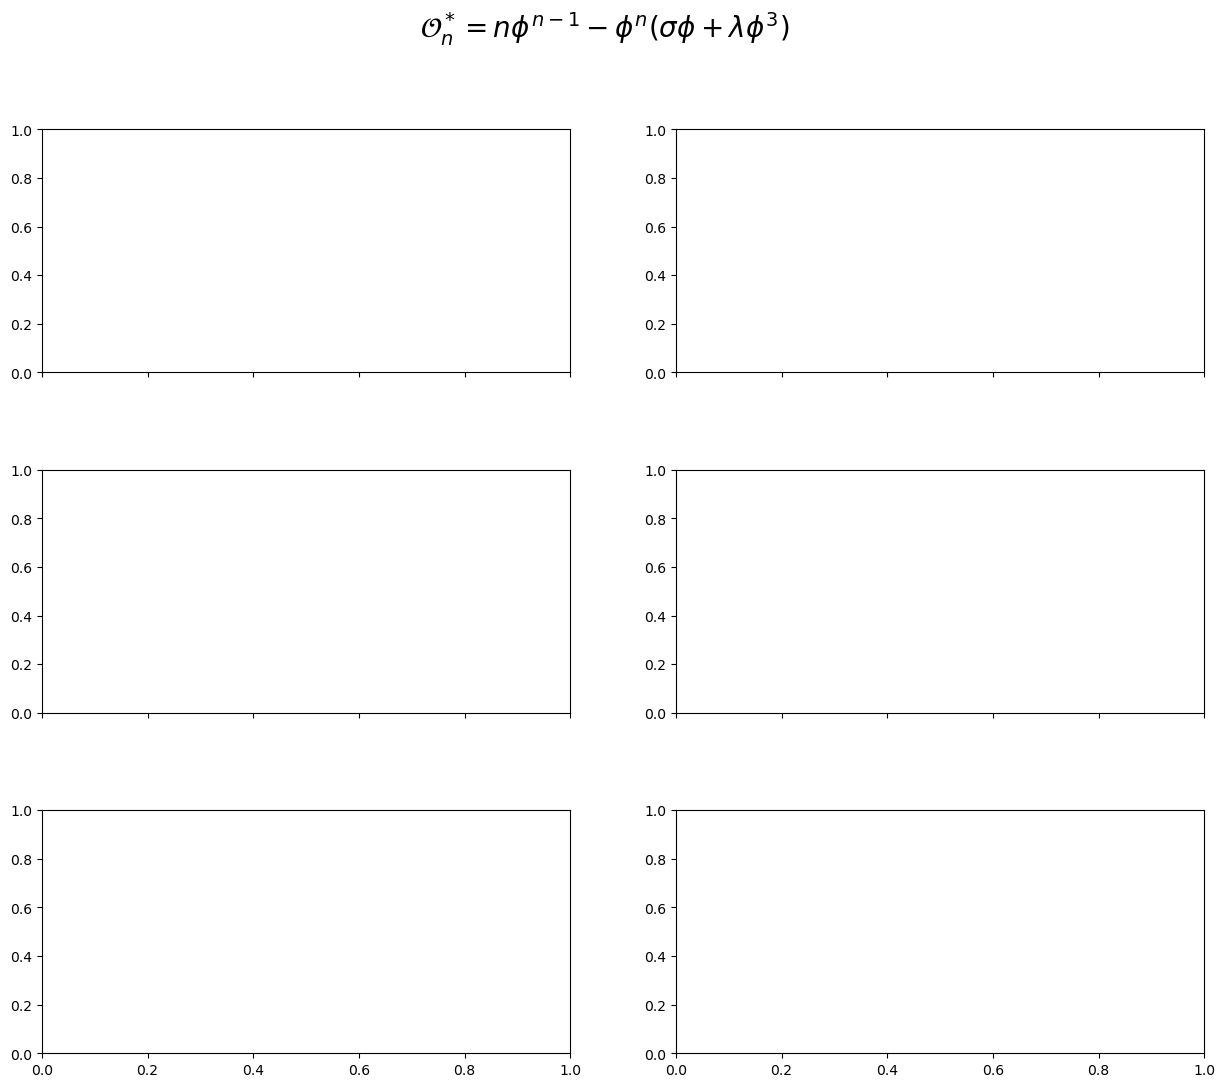

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(15, 4*3), sharex=True) 
fig.suptitle(rf"$\mathcal{{O}}^*_n=n \phi^{{n-1}}-\phi^n (\sigma\phi+\lambda \phi^3)$", fontsize = 20)
fig.subplots_adjust(hspace=0.4, wspace=0.2)  # Adjust spacing between subplots

for (name, tr), ax in zip(sim.trackers.items(), axes):

    order = tr.order
    # CL data
    cl_estimate = np.array(cl_estimate_dict_moments[name])
    errors = np.array(errors_dict_moments[name])
    vals_R = n_moment_dse_R_analytic(order=order, r = pullback, a = mass_modification, sigma=sigma_vals_cl, lamb=lamb)

    bias_corr_moments = cl_estimate + q_ana * (cl_estimate-vals_R)
    
    print(q_ana)
    ax[0].errorbar(angles_cl, bias_corr_moments.real, yerr=np.abs(error_prop), fmt='o',color='black', capsize=3 ,label='Complex Langevin', markersize=2)
    ax[1].errorbar(angles_cl, bias_corr_moments.imag, yerr=np.abs(error_prop), fmt='o',color='black', capsize=3 ,label='Complex Langevin', markersize=2)

    # Titles
    ax[0].set_title(rf'Real Part of Q'+r', $|\sigma| = $'+f"{sigma_abs}"+r', $\lambda=$'+f"{lamb}", fontsize=14)
    ax[1].set_title(rf'Imag Part of Q'+r', $|\sigma| = $'+f"{sigma_abs}"+r', $\lambda=$'+f"{lamb}", fontsize=14)

    # Thimble Sectors
    for ax_ in ax: 
        ax_.axvspan(0, np.pi/2, facecolor='green', alpha=0.4)
        ax_.axvspan(np.pi/2, 3*np.pi/2, facecolor='red', alpha=0.4)
        ax_.axvspan(3*np.pi/2, 2*np.pi, facecolor='green', alpha=0.4)

        
    vals_rho_tilde = n_moment_dse_rho_tilde(r=pullback, a=mass_modification, order= order, sigma=sigma_vals_cl, lamb=lamb)
    q_ana = 1 / (vals_R/vals_rho_tilde - 1)
    ax[0].plot(angles_cl, np.real(q_ana), label=rf"scipy")
    ax[1].plot(angles_cl, np.imag(q_ana), label=rf"scipy")
        
    # Formatting
    for ax_ in ax:
        ax_.set_xlabel(r'arg($\sigma$)', fontsize=12)
        ax_.grid(alpha=0.5, linestyle='--')
        ax_.legend(fontsize=10, loc = 'upper left')
        ax_.tick_params(axis='both', which='major', labelsize=10)
    
    # axes[0].set_ylim(-1, 1

    ax[0].set_xlim(angles_cl.min()*1.01, angles_cl.max()*1.01)
    ax[1].set_xlim(angles_cl.min()*1.01, angles_cl.max()*1.01)
    if order > 0: label = rf"$\langle {{{order}}} \cdot \phi^{{{order-1}}} - \phi^{{{order}}}(\sigma \phi + \lambda \phi^3) \rangle$"
    else: label = rf"$\langle \phi^{{{order}}}(\sigma \phi + \lambda \phi^3) \rangle$"

    ax[0].set_ylabel(rf'$n={{{order}}}$', fontsize=12)
    ax[1].set_ylabel(rf'$n={{{order}}}$', fontsize=12)

In [10]:
# Sim parameters
lamb = 1
sigma_abs = 5

start_angle = 0
stop_angle = 2*np.pi

num_cl = 16
angles_cl = np.linspace(start_angle, stop_angle, num_cl)
sigma_vals_cl = sigma_abs*(np.cos(angles_cl) + 1j*np.sin(angles_cl))

In [11]:
mass_modification = 2
pullback = 5

In [12]:
# # Running the simulation
# from simulation.config import Config
# from simulation.cl_simulation import ComplexLangevinSimulation
# from src.obs_kernels import n_moment_kernel, skew_action, dse_n_moment_kernel
# from src.utils import gaussian_modified_density_drift_kernel
# from tqdm import tqdm

# cl_estimate_dict = {'dse_1_moment': [], 'dse_3_moment': [], 'dse_5_moment': []}
# errors_dict = {'dse_1_moment': [], 'dse_3_moment': [], 'dse_5_moment': []}
# steps = int(1e4)
# trajs = int(1e4)


# for angle, sigma in zip(angles_cl, (sigma_vals_cl)):
#     config = Config(dt = 1e-3, trajs = trajs, dims = [1], mass_real = sigma, interaction = lamb, ada_step = True, drift_kernel=gaussian_modified_density_drift_kernel,
#                     mass_modification=mass_modification, pullback = pullback)
#     sim = ComplexLangevinSimulation(config)
    
#     sim.register_observable('dse_1_moment', obs_kernel=dse_n_moment_kernel, const_param={"order" : 1},  langevin_history=False, thermal_time=1, auto_corr=1)
#     sim.register_observable('dse_3_moment', obs_kernel=dse_n_moment_kernel, const_param={"order" : 3},  langevin_history=False, thermal_time=1, auto_corr=1)
#     sim.register_observable('dse_5_moment', obs_kernel=dse_n_moment_kernel, const_param={"order" : 5},  langevin_history=False, thermal_time=1, auto_corr=1)

#     for _ in tqdm(range(steps)):
#         sim.step()
#         for name, tr in sim.trackers.items():
#             tr.mark_equilibrated_trajs()
#             tr.compute()
#     sim.finish()

#     for name, tr in sim.trackers.items():
#         mean, sem = calculate_stats_complex(tr.rolling_mean, tr.rolling_sqr_mean, tr.counter)
#         cl_estimate_dict[name].append(mean)
#         errors_dict[name].append(sem)

100%|██████████| 10000/10000 [00:11<00:00, 864.22it/s]


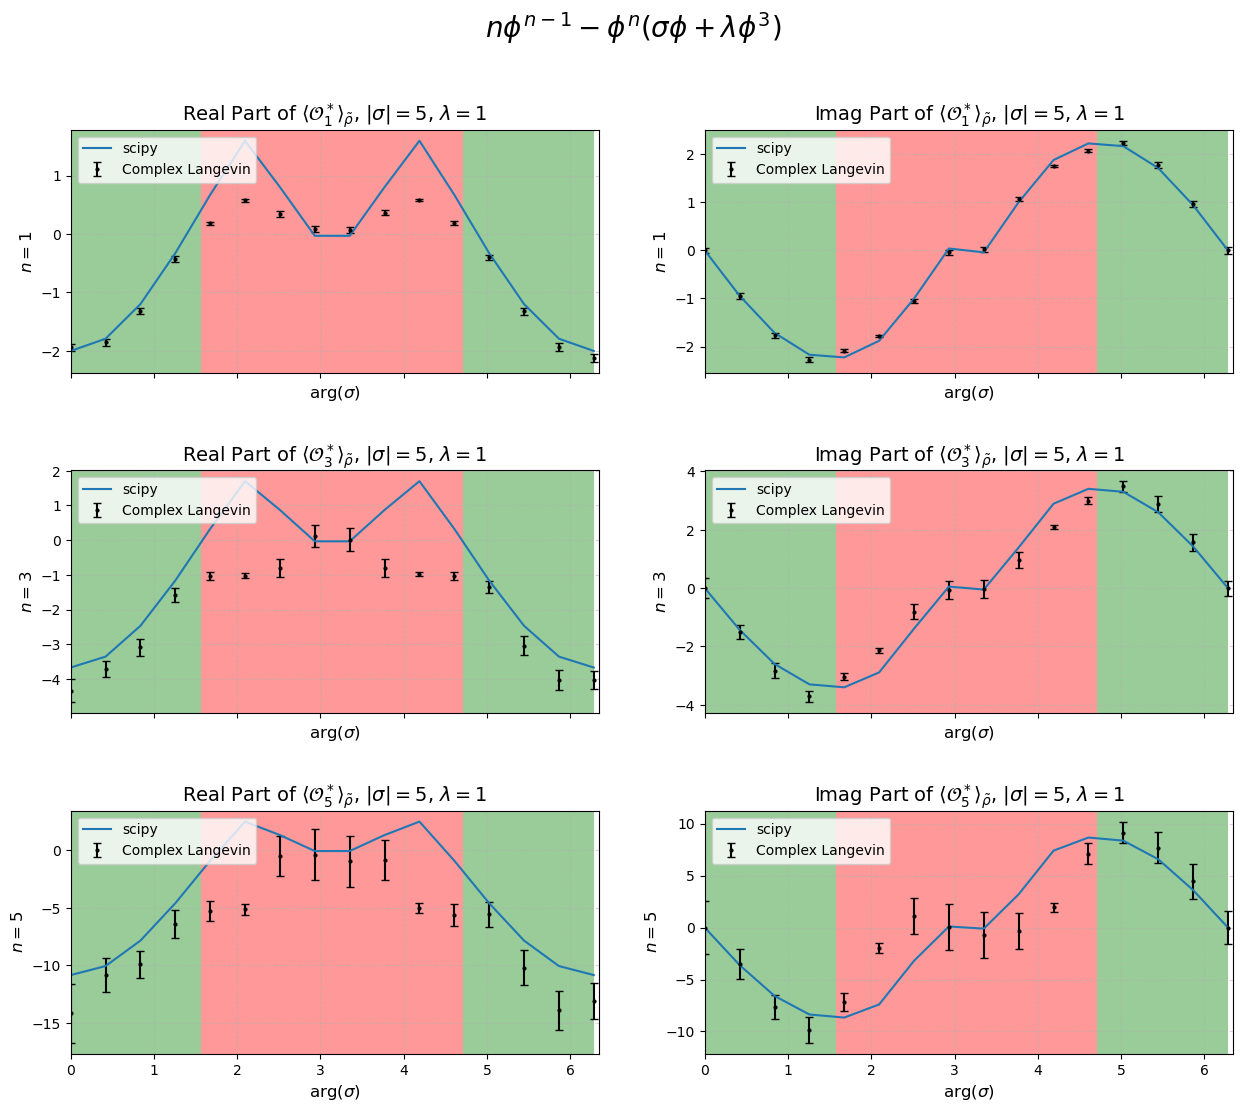

In [ ]:
# fig, axes = plt.subplots(3, 2, figsize=(15, 4*3), sharex=True) 
# fig.suptitle(rf"$n \phi^{{n-1}}-\phi^n (\sigma\phi+\lambda \phi^3)$", fontsize = 20)
# fig.subplots_adjust(hspace=0.4, wspace=0.2)  # Adjust spacing between subplots

# for (name, tr), ax in zip(sim.trackers.items(), axes):

#     order = tr.order
#     # CL data
#     cl_estimate = np.array(cl_estimate_dict[name])
#     errors = np.array(errors_dict[name])
#     ax[0].errorbar(angles_cl, cl_estimate.real, yerr=2*np.abs(errors), fmt='o',color='black', capsize=3 ,label='Complex Langevin', markersize=2)
#     ax[1].errorbar(angles_cl, cl_estimate.imag, yerr=2*np.abs(errors), fmt='o',color='black', capsize=3 ,label='Complex Langevin', markersize=2)

#     # Titles
#     ax[0].set_title(rf'Real Part of $\langle \mathcal{{O}}^*_{{{order}}}\rangle_{{\tilde{{\rho}}}}$'+r', $|\sigma| = $'+f"{sigma_abs}"+r', $\lambda=$'+f"{lamb}", fontsize=14)
#     ax[1].set_title(rf'Imag Part of $\langle \mathcal{{O}}^*_{{{order}}}\rangle_{{\tilde{{\rho}}}}$'+r', $|\sigma| = $'+f"{sigma_abs}"+r', $\lambda=$'+f"{lamb}", fontsize=14)

#     # Thimble Sectors
#     for ax_ in ax: 
#         ax_.axvspan(0, np.pi/2, facecolor='green', alpha=0.4)
#         ax_.axvspan(np.pi/2, 3*np.pi/2, facecolor='red', alpha=0.4)
#         ax_.axvspan(3*np.pi/2, 2*np.pi, facecolor='green', alpha=0.4)
#     vals_rho_tilde = n_moment_dse_rho_tilde(r=pullback, a=mass_modification, order= order, sigma=sigma_vals_cl, lamb=lamb)
#     ax[0].plot(angles_cl, np.real(vals_rho_tilde), label=rf"scipy")
#     ax[1].plot(angles_cl, np.imag(vals_rho_tilde), label=rf"scipy")
        
#     # Formatting
#     for ax_ in ax:
#         ax_.set_xlabel(r'arg($\sigma$)', fontsize=12)
#         ax_.grid(alpha=0.5, linestyle='--')
#         ax_.legend(fontsize=10, loc = 'upper left')
#         ax_.tick_params(axis='both', which='major', labelsize=10)
    
#     # axes[0].set_ylim(-1, 1

#     ax[0].set_xlim(angles_cl.min()*1.01, angles_cl.max()*1.01)
#     ax[1].set_xlim(angles_cl.min()*1.01, angles_cl.max()*1.01)
#     if order > 0: label = rf"$\langle {{{order}}} \cdot \phi^{{{order-1}}} - \phi^{{{order}}}(\sigma \phi + \lambda \phi^3) \rangle$"
#     else: label = rf"$\langle \phi^{{{order}}}(\sigma \phi + \lambda \phi^3) \rangle$"

#     ax[0].set_ylabel(rf'$n={{{order}}}$', fontsize=12)
#     ax[1].set_ylabel(rf'$n={{{order}}}$', fontsize=12)

dse_1_moment


NameError: name 'cl_estimate_dict_mod' is not defined

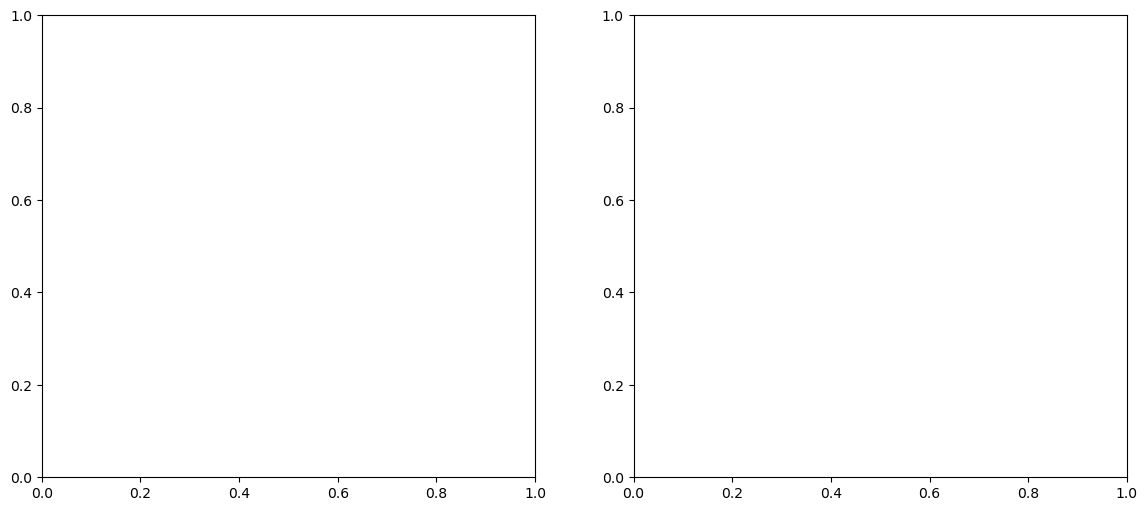

In [ ]:
for name, tr in sim.trackers.items():
    print(name)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
    order = tr.order
    # CL data
    cl_estimate = np.array(cl_estimate_dict_mod[name])
    errors = np.array(errors_dict_mod[name])
    axes[0].errorbar(angles_cl, cl_estimate.real, yerr=2*np.abs(errors), fmt='o',color='black', capsize=3 ,label='Complex Langevin', markersize=2)
    axes[1].errorbar(angles_cl, cl_estimate.imag, yerr=2*np.abs(errors), fmt='o',color='black', capsize=3 ,label='Complex Langevin', markersize=2)

    # Titles
    axes[0].set_title(rf'Real Part of $\langle \mathcal{{O}}^*_{{{order}}}\rangle$'+r', $|\sigma| = $'+f"{sigma_abs}"+r', $\lambda=$'+f"{lamb}", fontsize=14)
    axes[1].set_title(rf'Imaginary Part of $\langle \mathcal{{O}}^*_{{{order}}}\rangle$'+r', $|\sigma| = $'+f"{sigma_abs}"+r', $\lambda=$'+f"{lamb}", fontsize=14)
    
    # Thimble Sectors
    for ax in axes: 
        ax.axvspan(0, np.pi/2, facecolor='green', alpha=0.4)
        ax.axvspan(np.pi/2, 3*np.pi/2, facecolor='red', alpha=0.4)
        ax.axvspan(3*np.pi/2, 2*np.pi, facecolor='green', alpha=0.4)
        
    # Formatting
    for ax in axes:
        ax.set_xlabel(r'arg($\sigma$)', fontsize=12)
        ax.grid(alpha=0.5, linestyle='--')
        ax.legend(fontsize=10, loc = 'upper left')
        ax.tick_params(axis='both', which='major', labelsize=10)
    
    # axes[0].set_ylim(-1, 1

    # axes[0].set_xlim(angles_cl.min()*1.01, angles_cl.max()*1.01)
    # axes[1].set_xlim(angles_cl.min()*1.01, angles_cl.max()*1.01)
    if order > 0: label = rf"$\langle {{{order}}} \cdot \phi^{{{order-1}}} - \phi^{{{order}}}(\sigma \phi + \lambda \phi^3) \rangle$"
    else: label = rf"$\langle \phi^{{{order}}}(\sigma \phi + \lambda \phi^3) \rangle$"

    axes[0].set_ylabel(rf'Re {label}', fontsize=12)
    axes[1].set_ylabel(rf'Im {label}', fontsize=12)

NameError: name 'n_moment_dse_R' is not defined

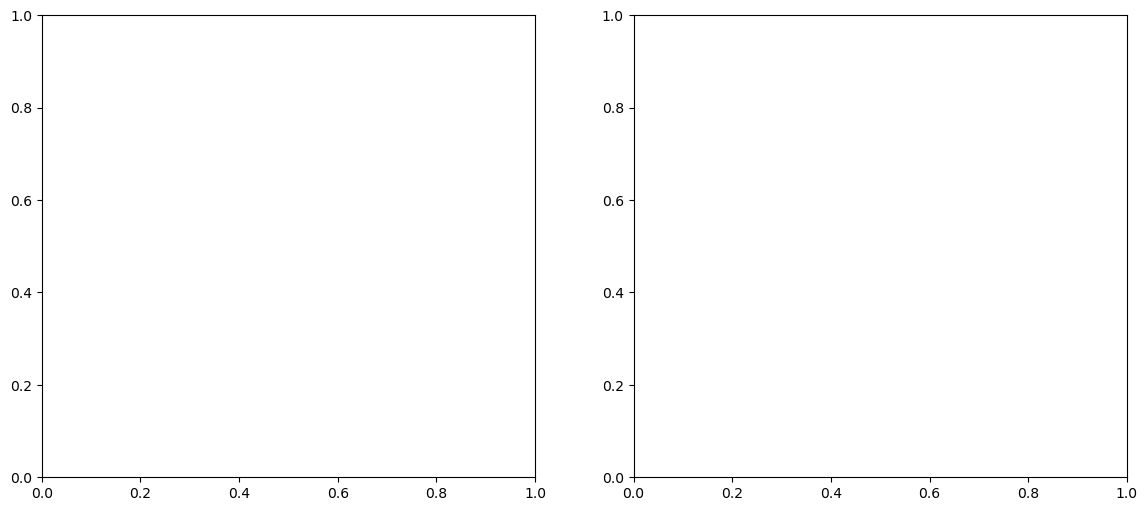

In [19]:
for (name, tr) in sim.trackers.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
    order = tr.const_param["order"]
    vals_R = n_moment_dse_R(r=5, a=2, order= order, sigma=sigma_vals_cl, lamb=1)

    cl_estimate = np.array(cl_estimate_dict_mod[name])
    errors = np.array(errors_dict_mod[name])
    q_cl = vals_R / (vals_R-cl_estimate)
    axes[0].plot(angles_cl, q_cl.real*2)
    axes[1].plot(angles_cl, q_cl.imag)

    vals_rho_tilde = n_moment_dse_rho_tilde(r=5, a=2, order= order, sigma=sigma_vals_cl, lamb=1)
    q_ana = vals_R / (vals_R-vals_rho_tilde)
    axes[0].plot(angles_cl, q_ana.real)
    axes[1].plot(angles_cl, q_ana.imag)

In [ ]:
for order, ax in zip(3, axes):
    vals_rho_tilde = n_moment_dse_rho_tilde(r=1, a=1, order= order, sigma=sigma_vals_cl, lamb=1)
    vals_R = n_moment_dse_R(r=1, a=1, order= order, sigma=sigma_vals_cl, lamb=1)
    

In [21]:
interaction = 1
sigma_abs = 1

start_angle = 0.01
stop_angle = np.pi

num = 9
angles = np.linspace(start_angle, stop_angle, num, endpoint=False)
sigma_vals = sigma_abs*(np.cos(angles) + 1j*np.sin(angles))

mass_modification = 1
pullback = 5
